<a href="https://colab.research.google.com/github/j-claudinei-f/j-claudinei-f/blob/main/Aula1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Derivadas Parciais e Aplicações**

José Claudinei Ferrerira

Universidade Federal de Alfenas

**Uma breve revisão**

Consideramos neste curso questões ligadas a funções de duas ou três varáveis. Essas questões estão ligadas a gráficos, áreas regiões e volumes de sólidos.



**Um exemplo de revisão: Sobre máximos e mínimos de uma função**

A função $f(x,y)=y^2-y^4-x^2$ é uma função contínua, que tem como domínio todo o plano $\mathbb{R}^2$, e possui derivadas de todas as ordens.

Em particular, temos as funções $$\frac{\partial f(x,y)}{\partial y}=-2x,\qquad \frac{\partial f(x,y)}{\partial y}=2y-4y^3,$$ que são derivadas parciais de primeira ordem de $f(x,y)$.

Podemos agora calcular valores dessas funções usando suas expressões e escolhendo valores para $x$ e $y$. Por exemplo, $$f(1,2)=2^2-2^4-1^2=-13, \frac{\partial f(0.5,0.75)}{\partial y}=-2\times 0.5=-1,\qquad \frac{\partial f(-0.5,0.75)}{\partial y}=2\times 0.75-4\times 0.75^3=-0.1875$$

In [ ]:
#@title Definição da função f(x, y) usando Python.
def f(x, y):
    return y**2 - y**4 - x**2

# Definição das derivadas parciais de primeira ordem.
def df_dx(x, y):
    return -2 * x

def df_dy(x, y):
    return 2 * y - 4 * y**3

f(1,2),df_dx(0.5,0.75), df_dy(-0.5,0.75)   # Chamada da função e das derivadas parcias.
                                               # O retorno é uma lista com valores reais.

(-13, -1.0, -0.1875)

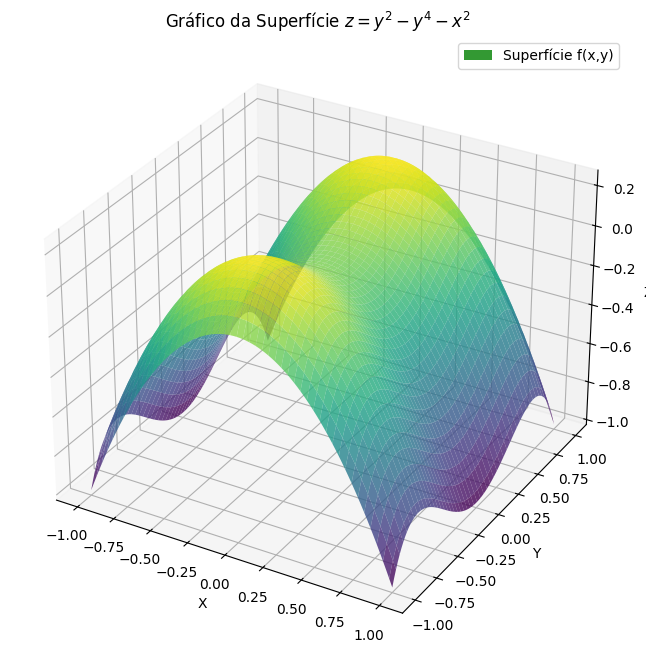

In [ ]:
#@title Gráfico da função $f(x,y)$.
import matplotlib.pyplot as plt, numpy as np
from mpl_toolkits.mplot3d import Axes3D

# Create a meshgrid for plotting the surface and plane
x_vals = np.linspace(-1, 1, 100)
y_vals = np.linspace(-1, 1, 100)
X, Y = np.meshgrid(x_vals, y_vals)

# Calculate Z for the surface
Z_surface = f(X, Y)

# Plotting
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot the surface
ax.plot_surface(X, Y, Z_surface, cmap='viridis', alpha=0.8, label='Superfície f(x,y)')

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title(f'Gráfico da Superfície $z=y^2-y^4-x^2$')

# Create dummy artists for legend workaround
surface_proxy = plt.Rectangle((0,0), 1, 1, fc="green", alpha=0.8)
plane_proxy = plt.Rectangle((0,0), 1, 1, fc="blue", alpha=0.5)
point_tangency_proxy = plt.Line2D([0],[0], linestyle="none", c='red', marker = 'o')

ax.legend([surface_proxy],
          ['Superfície f(x,y)'])

plt.show()

Podemos falar na derivada de $f(x,y)$ quando consideramos o vetor gradiente $$\nabla f(x,y)=\left(\frac{\partial f(x,y)}{\partial y},\frac{\partial f(x,y)}{\partial y}\right)=\left(-2x,2y-4y^3\right)=-2(x,y-2y^3).$$

Ainda, o vetor gradiente nos dá a direção em que a função cresce mais, quando seguimos em um trajeto cujo vetor velocidade tem módulo 1.

Nessas condições, por exemplo, no ponto $P=(0.5,0.75)$ a direção em que $f(x,y)$ cresce mais é a do vetor $$\nabla f(0.5,0.75)=(-1,-0.1875).$$

Como $f(x,y)=y^2-y^4-x^2=(1-y^2)y^2-x^2$ é negativa, para $|y|>1$, e $x^2$ e $y^2$ crescem quando $|x|$ e $|y|$ crescem, respectivamente, então $f(x,y)$ possui valor máximo. Podemos determinar algebricamente esse valor máximo obsevando quando $\nabla f(x,y)$ é nulo, no caso, quando $$x=0,\qquad y(1-2y^2)=0$$  que equivale aos pontos $$(0,0),\quad \left(0,\frac{\sqrt{2}}{2}\right),\quad \left(0,-\frac{\sqrt{2}}{2}\right).$$ Ou seja, o maior valor de $f(x,y)$ é $$f\left(0,-\frac{\sqrt{2}}{2}\right)=f\left(0,\frac{\sqrt{2}}{2}\right)=\frac{1}{4}.$$

Como temos o gráfico de $f(x,y)$ acima, vemos que o ponto $(0,0)$ é um ponto de sela.

In [ ]:
f(0,0),f(0,np.sqrt(2)/2), f(0,-np.sqrt(2)/2)

(0, np.float64(0.25000000000000006), np.float64(0.25000000000000006))

In [ ]:
#@title Definição do vetor $\nabla f(x,y)$ em Python.
import numpy as np
def grad_f(x,y):
  return  np.array([df_dx(x,y),df_dy(x,y)])

grad_f(0,np.sqrt(2)/2)

array([ 0.00000000e+00, -2.22044605e-16])

**Obs: Sobre o método dos gradientes.**

Por fim, nesse e em outros casos, o valor máximo de $f(x,y)$ poderia ser aproximado numéricamente pelo chamado método dos gradientes, que se resume a caminhar sobre o domínio da função, no caso o plano $xy$, partindo do ponto $(x_0,y_0)$ e dando passos pequenos na direção do vetor gradiente no ponto atingido no passo anterior.

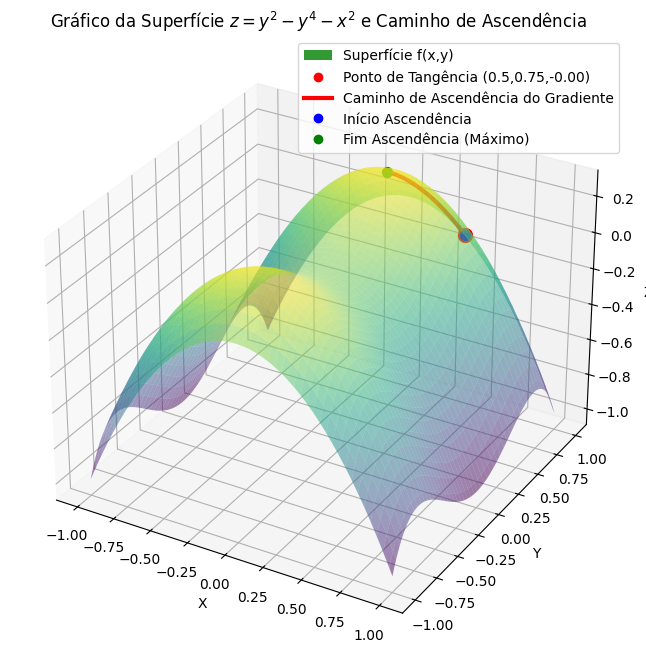

In [ ]:
#@title Método dos gradientes, com início no ponto $(0.5,0.75)$.
def gradient_ascent(start_point, learning_rate, iterations):
    path = [start_point]
    x, y = start_point
    for _ in range(iterations):
        grad_x = df_dx(x, y)
        grad_y = df_dy(x, y)
        x = x + learning_rate * grad_x
        y = y + learning_rate * grad_y
        path.append((x, y))
    return np.array(path)

# Parameters for gradient ascent
start_point_grad = (0.5, 0.75)
learning_rate_grad = 0.05
iterations_grad = 100

# Run gradient ascent to get the path
path_grad = gradient_ascent(start_point_grad, learning_rate_grad, iterations_grad)

# Calculate Z values for the gradient ascent path
z_path_grad = f(path_grad[:, 0], path_grad[:, 1])

# Define x0, y0, z0 for plotting purposes (taken from previous cell 4-eHeD2a94v5)
x0, y0 = .5, .75
z0 = f(x0, y0)

# Plotting
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot the surface
ax.plot_surface(X, Y, Z_surface, cmap='viridis', alpha=0.5, label='Superfície f(x,y)')

# Plot the point of tangency for the plane
ax.scatter([x0], [y0], [z0], color='red', s=100, label=f'Ponto de Tangência ({x0},{y0},{z0:.2f})')

# Plot the gradient ascent path
ax.plot(path_grad[:, 0], path_grad[:, 1], z_path_grad, color='red', linewidth=3, label='Caminho de Ascendência do Gradiente')
ax.scatter([path_grad[0,0]], [path_grad[0,1]], [f(path_grad[0,0], path_grad[0,1])], color='blue', s=50, label='Início Ascendência')
ax.scatter([path_grad[-1,0]], [path_grad[-1,1]], [f(path_grad[-1,0], path_grad[-1,1])], color='green', s=50, label='Fim Ascendência (Máximo)')

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title(f'Gráfico da Superfície $z=y^2-y^4-x^2$ e Caminho de Ascendência')

# Create dummy artists for legend workaround
surface_proxy = plt.Rectangle((0,0), 1, 1, fc="green", alpha=0.8)
plane_proxy = plt.Rectangle((0,0), 1, 1, fc="blue", alpha=0.5)
point_tangency_proxy = plt.Line2D([0],[0], linestyle="none", c='red', marker = 'o')
gradient_path_proxy = plt.Line2D([0],[0], linestyle="-", color='red', linewidth=3)
start_ascent_proxy = plt.Line2D([0],[0], linestyle="none", c='blue', marker = 'o')
end_ascent_proxy = plt.Line2D([0],[0], linestyle="none", c='green', marker = 'o')

ax.legend([surface_proxy, point_tangency_proxy, gradient_path_proxy, start_ascent_proxy, end_ascent_proxy],
          ['Superfície f(x,y)', f'Ponto de Tangência ({x0},{y0},{z0:.2f})', 'Caminho de Ascendência do Gradiente', 'Início Ascendência', 'Fim Ascendência (Máximo)'])

plt.show()

Para terminar essa breve revisão, cabe lembrar que uma curva de nível $c$ de $f(x,y)$ é um subconjunto do plano $xy$ em que $f(x,y)=c$. Curvas de nível são muito úteis para entendermos o comportamento de $f(x,y)$. E um fato importante é que o vetor gradiente $\nabla f(x_0,y_0)$ aponta numa direção perpendicular a uma curva de nível que passa pelo ponto $(x_0,y_0)$.

Ponto inicial: [0.5  0.75]
Ponto de máximo encontrado (x, y): (0.0000, 0.7071)
Valor máximo da função (z): 0.2500


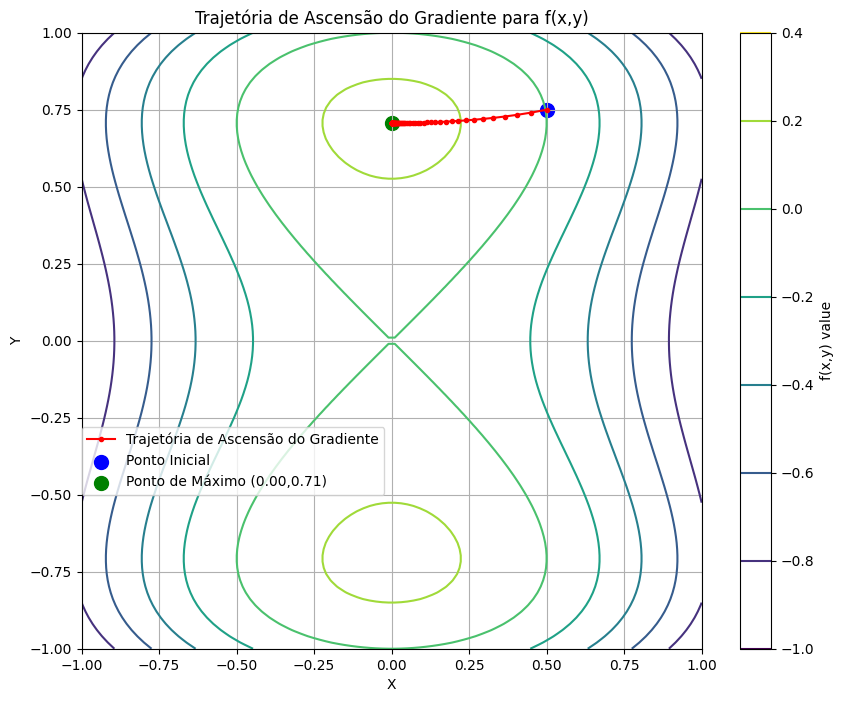

In [ ]:
#@title Método dos gradientes mostrado no domínio, com auxílio das curvas de nível de $f(x,y)$.
path = path_grad

# Get the final point
max_x, max_y = path[-1]
max_z = f(max_x, max_y)
start_point = path[0]
print(f"Ponto inicial: {start_point}")
print(f"Ponto de máximo encontrado (x, y): ({max_x:.4f}, {max_y:.4f})")
print(f"Valor máximo da função (z): {max_z:.4f}")

# Plotting the contour plot and the ascent path
Z = f(X, Y)

lev=[-1,-0.5,0.25,-0.3,0.2,0.1,-0.6,-0.4].sort()
plt.figure(figsize=(10, 8))
plt.contour(X, Y, Z, levels=lev, cmap='viridis')
plt.colorbar(label='f(x,y) value')
plt.plot(path[:, 0], path[:, 1], color='red', marker='o', linestyle='-', markersize=3, label='Trajetória de Ascensão do Gradiente')
plt.scatter(start_point[0], start_point[1], color='blue', s=100, label='Ponto Inicial')
plt.scatter(max_x, max_y, color='green', s=100, label=f'Ponto de Máximo ({max_x:.2f},{max_y:.2f})')

plt.title('Trajetória de Ascensão do Gradiente para f(x,y)')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend(loc=(0, 0.25))
plt.grid(True)
plt.show()

**Exemplo: Sobre plano tangente a superfícies**

Na Geometria Analítica sabemos que três pontos distintos de um plano, não colineares, determinam unicamente esse plano. De fato, se $P_0$, $P_1$ e $P_2$ são três pontos do plano, podemos formar os vetores

$$
u=P_1-P_0, \qquad v=P_2-P_0.
$$

Esses dois vetores fornecem duas direções do plano. Assim, uma equação paramétrica do plano é

$$
P(s,t)=P_0+s\,u+t\,v, \qquad s,t\in\mathbb{R}.
$$

Além disso, um vetor normal ao plano pode ser obtido pelo produto vetorial

$$
n=u\times v.
$$

Agora considere o gráfico de uma função $z=f(x,y)$. Os pontos dessa superfície têm a forma

$$
(x,y,f(x,y)).
$$

Fixe um ponto da superfície

$$
P=(x_0,y_0,z_0),
$$

onde $z_0=f(x_0,y_0)$.

Escolhendo números reais não nulos $h$ e $k$, consideramos dois pontos próximos no gráfico:

$$
P_1=(x_0+h,y_0,f(x_0+h,y_0)),
$$

$$
P_2=(x_0,y_0+k,f(x_0,y_0+k)).
$$

Os três pontos $P$, $P_1$ e $P_2$ pertencem ao gráfico da função. A partir deles obtemos dois vetores contidos na superfície:

$$
u=P_1-P=(h,0,f(x_0+h,y_0)-f(x_0,y_0)),
$$

$$
v=P_2-P=(0,k,f(x_0,y_0+k)-f(x_0,y_0)).
$$

Dividindo esses vetores por $h$ e $k$, respectivamente, obtemos

$$
\frac{u}{h}=\left(1,0,\frac{f(x_0+h,y_0)-f(x_0,y_0)}{h}\right),
$$

$$
\frac{v}{k}=\left(0,1,\frac{f(x_0,y_0+k)-f(x_0,y_0)}{k}\right).
$$

Quando $h\to 0$ e $k\to 0$, os quocientes incrementais convergem para as derivadas parciais da função:

$$
\lim_{h\to0}\frac{f(x_0+h,y_0)-f(x_0,y_0)}{h}=f_x(x_0,y_0),
$$

$$
\lim_{k\to0}\frac{f(x_0,y_0+k)-f(x_0,y_0)}{k}=f_y(x_0,y_0).
$$

Assim, os vetores $\frac{u}{h}$ e $\frac{v}{k}$ aproximam-se das direções

$$
(1,0,f_x(x_0,y_0)), \qquad (0,1,f_y(x_0,y_0)).
$$

Esses dois vetores geram o plano tangente ao gráfico de $f$ no ponto $P=(x_0,y_0,z_0)$. Portanto, uma parametrização do plano tangente é

$$
(x,y,z)=(x_0,y_0,z_0)+s(1,0,f_x(x_0,y_0))+t(0,1,f_y(x_0,y_0)).
$$

Um vetor normal ao plano tangente pode ser obtido pelo produto vetorial dessas duas direções:

$$
n=(1,0,f_x(x_0,y_0))\times(0,1,f_y(x_0,y_0)).
$$

Calculando o produto vetorial, temos
$$
n=
\begin{vmatrix}
\mathbf{i} & \mathbf{j} & \mathbf{k}\\
1 & 0 & f_x(x_0,y_0)\\
0 & 1 & f_y(x_0,y_0)
\end{vmatrix}.
$$

Calculando o determinante, obtemos

$$
n=(-f_x(x_0,y_0),-f_y(x_0,y_0),1).
$$

Consequentemente, a equação do plano tangente pode ser escrita como

$$
z-z_0=f_x(x_0,y_0)(x-x_0)+f_y(x_0,y_0)(y-y_0).
$$

$$
n=(-f_x(x_0,y_0),-f_y(x_0,y_0),1).
$$

Consequentemente, a equação do plano tangente pode ser escrita como

$$
z-z_0=f_x(x_0,y_0)(x-x_0)+f_y(x_0,y_0)(y-y_0).
$$

Outra utilidade do vetor gradiente é na determinação do plano tangente ao gráfico de $f(x,y)$, por um ponto $(x_0,y_0)$ fixado.

Nesse caso, temos a aproximação $$f(x,y)\approx f(x_0,y_0)+\nabla f(x_0,y_0)\cdot (x-x_0,y-y_0),$$ que nos dá o plano tangente ao gráfico como $$T:\, (x,y,z)=(x,y,f(x_0,y_0)+\nabla f(x_0,y_0)\cdot (x-x_0,y-y_0)).$$

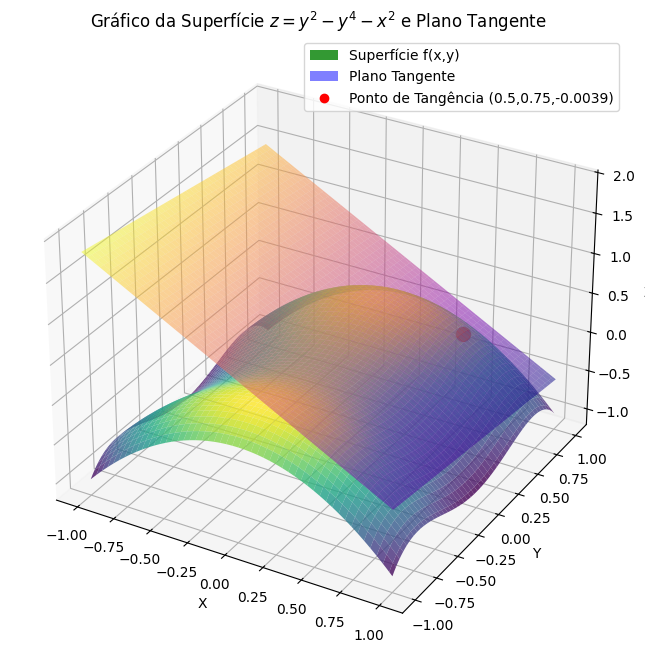

In [ ]:
#@title Gráfico da função $f(x,y)$ e da aproximação do gráfico por plano tangente, no ponto $(0.5,0.75)$.
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Point of tangency for the plane
x0, y0 = .5, .75
z0 = f(x0, y0)

# Evaluate partial derivatives at (x0, y0) for the plane
fx0 = df_dx(x0, y0)
fy0 = df_dy(x0, y0)

# Equation of the tangent plane: Z - z0 = fx0*(X - x0) + fy0*(Y - y0)
# Z = z0 + fx0*(X - x0) + fy0*(Y - y0)
def tangent_plane(x, y, x0, y0, z0, fx0, fy0):
    return z0 + fx0 * (x - x0) + fy0 * (y - y0)

# Calculate Z for the tangent plane
Z_plane = tangent_plane(X, Y, x0, y0, z0, fx0, fy0)


# Plotting
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot the surface
ax.plot_surface(X, Y, Z_surface, cmap='viridis', alpha=0.8, label='Superfície f(x,y)')

# Plot the tangent plane
ax.plot_surface(X, Y, Z_plane, cmap='plasma', alpha=0.5, label='Plano Tangente')

# Plot the point of tangency for the plane
ax.scatter([x0], [y0], [z0], color='red', s=100, label=f'Ponto de Tangência ({x0},{y0},{z0:.4f})')

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title(f'Gráfico da Superfície $z=y^2-y^4-x^2$ e Plano Tangente')

# Create dummy artists for legend workaround
surface_proxy = plt.Rectangle((0,0), 1, 1, fc="green", alpha=0.8)
plane_proxy = plt.Rectangle((0,0), 1, 1, fc="blue", alpha=0.5)
point_tangency_proxy = plt.Line2D([0],[0], linestyle="none", c='red', marker = 'o')

ax.legend([surface_proxy, plane_proxy, point_tangency_proxy],
          ['Superfície f(x,y)', 'Plano Tangente', f'Ponto de Tangência ({x0},{y0},{z0:.4f})'])

plt.show()

**Um problema: Iniciando a visualização de sólidos formados por superfícies**

Vamos considerar agora que o domínio da função $f(x,y)$ é o quadrado
$$
[-1,1]\times[-1,1]
$$
no plano $\mathbb{R}^2$.

Para descrever o bordo dessa região, podemos utilizar uma curva parametrizada.
Seja $t\in[0,4]$. Nesse intervalo, cada subintervalo de comprimento $1$
corresponde a um dos lados do quadrado. Assim, o bordo pode ser descrito por

$$
(x(t),y(t))=
\begin{cases}
(-1+2t,-1), & 0\le t<1,\\[6pt]
(1,-1+2(t-1)), & 1\le t<2,\\[6pt]
(1-2(t-2),1), & 2\le t<3,\\[6pt]
(-1,1-2(t-3)), & 3\le t\le4.
\end{cases}
$$

Essa parametrização define uma curva fechada no plano $xy$ que percorre
todo o contorno da região $[-1,1]\times[-1,1]$.

Ao considerarmos agora o gráfico da função $U(x,y)$, cada ponto do bordo
do quadrado é elevado até a altura determinada por essa função. Dessa forma,
obtemos uma curva espacial dada por

$$
\gamma(t)=\big(x(t),y(t),U(x(t),y(t))\big), \qquad 0\le t\le4.
$$

Essa curva corresponde ao contorno do gráfico da superfície sobre a
região considerada e será utilizada para visualizar o sólido limitado
pela superfície $z=U(x,y)$ e pela região quadrada no plano $xy$.

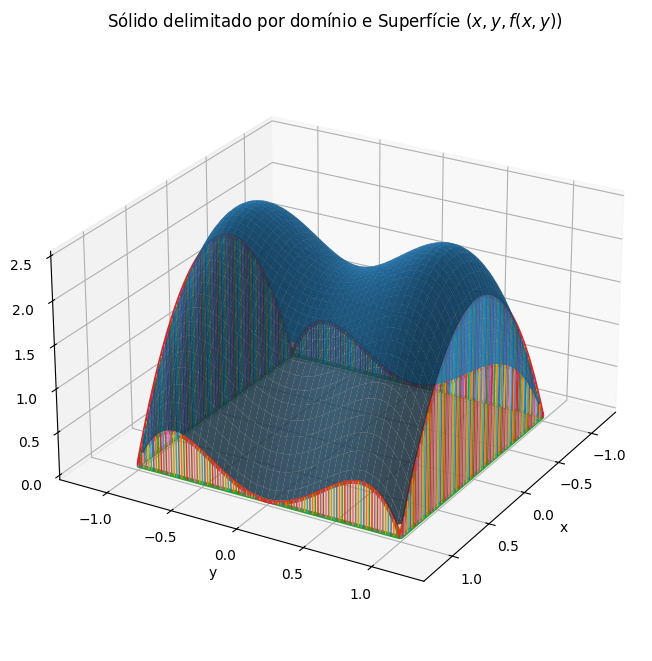

In [2]:
#@title Sólido entre o gráfico de 2(f(x,y)+1) e a região R

import numpy as np
import matplotlib.pyplot as plt


# ======================================================
# FUNÇÕES
# ======================================================

def f(x,y):
    return y**2 - y**4 - x**2

def U(x,y):
    return 2*(f(x,y) + 1)


# ======================================================
# MALHA DA SUPERFÍCIE
# ======================================================

x = np.linspace(-1.2,1.2,200)
y = np.linspace(-1.2,1.2,200)

X,Y = np.meshgrid(x,y)

Z = U(X,Y)

# região R = [-1,1] x [-1,1]
mask = (np.abs(X) <= 1) & (np.abs(Y) <= 1)

Z[~mask] = np.nan


# ======================================================
# BASE DO SÓLIDO
# ======================================================

Z0 = np.zeros_like(X)
Z0[~mask] = np.nan


# ======================================================
# BORDO DO QUADRADO
# ======================================================

t = np.linspace(0,4,400)

xb = np.zeros_like(t)
yb = np.zeros_like(t)

# lado inferior
m = (t>=0) & (t<1)
xb[m] = -1 + 2*t[m]
yb[m] = -1

# lado direito
m = (t>=1) & (t<2)
xb[m] = 1
yb[m] = -1 + 2*(t[m]-1)

# lado superior
m = (t>=2) & (t<3)
xb[m] = 1 - 2*(t[m]-2)
yb[m] = 1

# lado esquerdo
m = (t>=3) & (t<=4)
xb[m] = -1
yb[m] = 1 - 2*(t[m]-3)

zb = U(xb,yb)


# ======================================================
# FIGURA
# ======================================================

fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(projection='3d')


# superfície superior
ax.plot_surface(X,Y,Z,alpha=0.8)


# base do sólido
ax.plot_surface(X,Y,Z0,alpha=0.3)


# bordo da base
ax.plot(xb,yb,0*xb,linewidth=3)


# bordo superior
ax.plot(xb,yb,zb,linewidth=3)


# paredes laterais
for i in range(0,len(t)):
    ax.plot([xb[i],xb[i]],
            [yb[i],yb[i]],
            [0,zb[i]],
            linewidth=1)


# ======================================================
# AJUSTES DO GRÁFICO
# ======================================================

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")

ax.set_box_aspect([1,1,0.6])

ax.view_init(elev=25, azim=30)
ax.set_title(f'Sólido delimitado por domínio e Superfície $(x,y,f(x,y))$')
plt.show()

**a)** Determine as expressões da funções $f(x,y)$ restrita a cada lado do quadrado $[-1,1]\times[-1,1]$, isto é,
quando $(x,y)$ pertence aos segmentos
$x=-1$, $x=1$, $y=-1$ e $y=1$.

**b)**  Para a curva $\gamma(t)$ definida no item anterior,
determine a reta tangente em um ponto pertencente a cada um dos
quatro lados do quadrado $[-1,1]\times[-1,1]$.

**Problema: Sobre o plano tangente a superfícies mais gerais**

Considere a função
$$
F(x,y)=(d(x,y),e(x,y),f(x,y))=(xy+x^3,x^2-2xy^2,y^2-y^4-x^2).
$$

Essa função define uma superfície parametrizada no $\mathbb{R}^3$. Cada ponto da superfície é obtido variando os parâmetros $(x,y)$.

Para determinar o plano tangente a essa superfície em um ponto, calculamos os vetores tangentes obtidos pelas derivadas parciais da parametrização:

$$
F_x(x,y)=\frac{\partial F}{\partial x}(x,y),
\qquad
F_y(x,y)=\frac{\partial F}{\partial y}(x,y).
$$

Esses dois vetores pertencem ao plano tangente da superfície no ponto considerado. Assim, uma parametrização do plano tangente no ponto
$$
P=F(x_0,y_0)
$$
é dada por

$$
(x,y,z)=F(x_0,y_0)+sF_x(x_0,y_0)+tF_y(x_0,y_0).
$$

Um vetor normal ao plano tangente pode ser obtido pelo produto vetorial

$$
n=F_x(x_0,y_0)\times F_y(x_0,y_0).
$$

Podemos utilizar o Python para gerar uma visualização dessa superfície parametrizada.

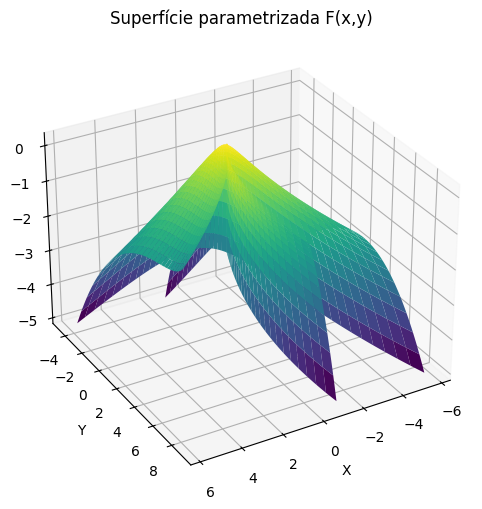

In [ ]:
#@title Imagem da superfície
import numpy as np
import matplotlib.pyplot as plt

# =========================
# Definição da parametrização
# =========================
def d(x,y):
    return x*y + x**3

def e(x,y):
    return x**2 - 2*x*y**2

def f(x,y):
    return y**2 - y**4 - x**2

# =========================
# Domínio dos parâmetros
# =========================
x = np.linspace(-1.5,1.5,200)
y = np.linspace(-1.5,1.5,200)

X, Y = np.meshgrid(x,y)

# =========================
# Superfície
# =========================
X3 = d(X,Y)
Y3 = e(X,Y)
Z3 = f(X,Y)

# =========================
# Gráfico
# =========================
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(X3, Y3, Z3, cmap='viridis', edgecolor='none')

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title('Superfície parametrizada F(x,y)')
ax.view_init(elev=30, azim=60)
plt.show()

**Plano tangente para $x=1,\;y=1$:**

Considere a superfície parametrizada

$$
F(x,y)=(d(x,y),e(x,y),f(x,y))=(xy+x^3,\;x^2-2xy^2,\;y^2-y^4-x^2).
$$

**1. Vetores tangentes**

Calculamos as derivadas parciais da parametrização.

$$
F_x(x,y)=\left(\frac{\partial d}{\partial x},\frac{\partial e}{\partial x},\frac{\partial f}{\partial x}\right)
$$

$$
F_x(x,y)=(y+3x^2,\;2x-2y^2,\;-2x)
$$

$$
F_y(x,y)=\left(\frac{\partial d}{\partial y},\frac{\partial e}{\partial y},\frac{\partial f}{\partial y}\right)
$$

$$
F_y(x,y)=(x,\;-4xy,\;2y-4y^3)
$$

**2. Avaliação no ponto** $(x,y)=(1,1)$

Primeiro calculamos o ponto da superfície

$$
P=F(1,1)
$$

$$
P=(2,-1,-1)
$$

Agora os vetores tangentes

$$
F_x(1,1)=(4,0,-2)
$$

$$
F_y(1,1)=(1,-4,-2)
$$

**3. Vetor normal**

O vetor normal ao plano tangente é dado pelo produto vetorial

$$
n=F_x(1,1)\times F_y(1,1)
$$

$$
n=
\begin{vmatrix}
\mathbf{i} & \mathbf{j} & \mathbf{k}\\
4 & 0 & -2\\
1 & -4 & -2
\end{vmatrix}
$$

Calculando

$$
n=
\mathbf{i}
\begin{vmatrix}
0 & -2\\
-4 & -2
\end{vmatrix}
-
\mathbf{j}
\begin{vmatrix}
4 & -2\\
1 & -2
\end{vmatrix}
+
\mathbf{k}
\begin{vmatrix}
4 & 0\\
1 & -4
\end{vmatrix}
$$

$$
n=(-8,6,-16)
$$

Podemos simplificar

$$
n=(-4,3,-8)
$$

**4. Plano tangente**

A equação do plano com normal $n=(-4,3,-8)$ passando por
$P=(2,-1,-1)$ é

$$
-4(x-2)+3(y+1)-8(z+1)=0
$$

Simplificando

$$
4x-3y+8z-3=0
$$

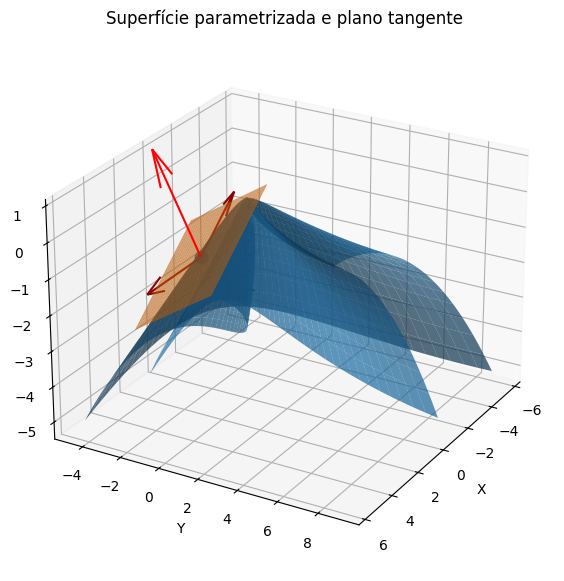

In [ ]:
#@title Superfície, vetores tangentes, vetor normal e plano tangente, no ponto $F(1,1)=(2,-1,-1)$.
import numpy as np
import matplotlib.pyplot as plt

# =====================================
# Parametrização da superfície
# =====================================

def d(x,y):
    return x*y + x**3

def e(x,y):
    return x**2 - 2*x*y**2

def f(x,y):
    return y**2 - y**4 - x**2


# =====================================
# Malha da superfície
# =====================================

x = np.linspace(-1.5,1.5,200)
y = np.linspace(-1.5,1.5,200)

X,Y = np.meshgrid(x,y)

X3 = d(X,Y)
Y3 = e(X,Y)
Z3 = f(X,Y)


# =====================================
# Ponto de tangência
# =====================================

x0 = 1
y0 = 1

P = np.array([
    d(x0,y0),
    e(x0,y0),
    f(x0,y0)
])


# =====================================
# Vetores tangentes
# =====================================

Fx = -np.array([4,0,-2])
Fy = np.array([1,-4,-2])

# vetor normal
n = np.cross(Fx,Fy)


# =====================================
# Plano tangente
# 4x - 3y + 8z - 3 = 0
# =====================================

xp = np.linspace(0,4,30)
yp = np.linspace(-3,1,30)

Xp,Yp = np.meshgrid(xp,yp)

Zp = (3 - 4*Xp + 3*Yp)/8


# =====================================
# Gráfico
# =====================================

fig = plt.figure(figsize=(9,7))
ax = fig.add_subplot(111,projection='3d')

# superfície
ax.plot_surface(X3,Y3,Z3,alpha=0.7)

# plano tangente
ax.plot_surface(Xp,Yp,Zp,alpha=0.6)

# ponto
ax.scatter(P[0],P[1],P[2],s=80)

# vetores tangentes
ax.quiver(P[0],P[1],P[2],
          Fx[0],Fx[1],Fx[2],
          length=0.6,color='darkred')

ax.quiver(P[0],P[1],P[2],
          Fy[0],Fy[1],Fy[2],
          length=0.6,color='darkred')

# vetor normal
ax.quiver(P[0],P[1],P[2],
          n[0],n[1],n[2],
          length=0.2,color='red')


# =====================================
# rótulos
# =====================================

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')

ax.set_title("Superfície parametrizada e plano tangente")

# =====================================
# Rotação no plano da base
# (deixa o plano tangente mais visível)
# =====================================

ax.view_init(elev=25, azim=30)

plt.show()

**a)** Calcule os vetores gradientes das funções coordenadas
$d(x,y)$, $e(x,y)$ e $f(x,y)$ da aplicação $F:\mathbb{R}^2\to\mathbb{R}^3$.

**b)** Determine a matriz jacobiana $JF(x,y)$ da aplicação $F$.

**c)** Determine a equação do plano tangente à superfície parametrizada
por $F(x,y)$ no ponto $F(-1,1)$. Apresente a equação do plano tangente
tanto na forma paramétrica quanto na forma cartesiana (reduzida).

**Referências**

1. Thomas, G. B., Cálculo, Vol. 2, Addison Wesley, São Paulo, 2009.